01_data_preparation

02_feature_extraction_and_ml_traning

03_acoustic_DL

04_linguistic_DL

05_image_DL

# Imports

In [ ]:
!pip install google-cloud-storage pydub librosa matplotlib openai-whisper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 48.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for openai-whisper: filename=openai_whisper-20250625-py3-none-any.whl size=803979 sha256=a62df5541fcefb9a5fe273802d3c1c6abe63ade1f9e8f32132b1ce98ca4cc38a
  Stored in directory: /root/.cache/pip/wheels/61/d2/20/09ec9bef734d126cba375b15898010b6cc28578d8afdde5869
Successfully built openai-whisper


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob


# Configurations

In [ ]:
from google.colab import auth
auth.authenticate_user()

# To find the credentials automatically
from google.cloud import storage
client = storage.Client(project=GCP_PROJECT_ID) # GCP Project ID

In [ ]:
# Initialize GCP Storage
client = storage.Client()
bucket_name = VOICE_DATA_BUCKET_NAME # GCP Storage bucket name
bucket = client.get_bucket(bucket_name)
print(f"Bucket {bucket.name} successfully loaded.")

Bucket voicedata-bucket successfully loaded.


In [ ]:

print(os.getcwd()) 

/content


In [ ]:
# Configuration
PREFIX_AUDIO = 'ADDReSS2021/train/audio'
PREFIX_SEG = 'ADDReSS2021/train/segmentation'
CATEGORIES = ['CN', 'AD']

# Ensure local directories exist for processing
os.makedirs("local_data/audio", exist_ok=True)
os.makedirs("local_data/segmentation", exist_ok=True)
os.makedirs("local_data/processed_audio", exist_ok=True)

# Create Ground Truth CSV (extract labels for audio files)

In [ ]:
# Generate Ground Truth CSV
# uses the GCS bucket to figure out which patient belongs to which category.

ground_truth_data = []

print("Scanning GCS bucket to generate ground truth labels for ADDReSSo dataset...")

for category in CATEGORIES:
    category_prefix = f"{PREFIX_AUDIO}/{category}/"
    blobs = bucket.list_blobs(prefix=category_prefix)

    for blob in blobs:
        if blob.name.endswith('.wav'):
            # Extract just the ID (e.g., 'ADDReSS2021/train/audio/AD/adrso024.wav' -> 'adrso024')
            file_name = blob.name.split('/')[-1]
            participant_id = file_name.replace('.wav', '')

            ground_truth_data.append({
                "participant_id": participant_id,
                "label": category,
                "label_numeric": 1 if category == 'AD' else 0 # CN = 0, AD = 1
            })

# Create the Ground Truth dataframe and save it as a CSV
gt_df = pd.DataFrame(ground_truth_data)
gt_df.to_csv("local_data/ground_truth.csv", index=False)

print(f"Success! Created ground truth for {len(gt_df)} participants.")
display(gt_df.head())

Scanning GCS bucket to generate ground truth labels for ADDReSSo dataset...
Success! Created ground truth for 166 participants.


,participant_id,label,label_numeric
0,adrso002,CN,0
1,adrso003,CN,0
2,adrso005,CN,0
3,adrso007,CN,0
4,adrso008,CN,0


# Extract Participant Speech

Raw Audio => Segmentation => Participant-only Audio => ASR => Participant-only Transcripts

In [ ]:
from pydub import AudioSegment

# Audio Extraction Function
def extract_address_participant_audio(audio_path, seg_df, output_path):
    """
    Extracts the full duration of the participant's test, preserving pauses,
    while removing investigator (INV) interruptions based on the segmentation CSV.
    Returns: (is_corrupted, error_message)
    """
    try:
        # 1. Integrity Check: Decode Audio
        try:
            audio = AudioSegment.from_wav(audio_path)
        except Exception as e:
            return True, f"Failed to decode raw audio: {e}"

        par_segments = seg_df[seg_df['speaker'] == 'PAR']
        inv_segments = seg_df[seg_df['speaker'] == 'INV']

        if par_segments.empty:
            return True, "No 'PAR' segments found in segmentation file."

        # 2. Create the "Bounding Box" (using millisecond conversion if needed)
        # Assuming the CSV 'begin' and 'end' are in milliseconds
        first_par_start = int(par_segments['begin'].min())
        last_par_end = int(par_segments['end'].max())

        keep_intervals = [{'start': first_par_start, 'end': last_par_end}]

        # 3. Subtract Investigator Interruptions
        for _, inv in inv_segments.iterrows():
            inv_start = int(inv['begin'])
            inv_end = int(inv['end'])
            new_keep = []

            for interval in keep_intervals:
                if inv_end <= interval['start'] or inv_start >= interval['end']:
                    new_keep.append(interval) # No overlap
                else:
                    # Overlap exists. Split around the investigator's speech
                    if interval['start'] < inv_start:
                        new_keep.append({'start': interval['start'], 'end': inv_start})
                    if interval['end'] > inv_end:
                        new_keep.append({'start': inv_end, 'end': interval['end']})
            keep_intervals = new_keep

        # 4. Extract and Concatenate
        participant_audio = AudioSegment.empty()
        for interval in keep_intervals:
            participant_audio += audio[interval['start']:interval['end']]

        # 5. Export Processed Audio
        participant_audio.export(output_path, format="wav")

        # 6. Integrity Check: Verify Export
        if os.path.getsize(output_path) == 0:
            return True, "Exported audio file is 0 bytes."

        return False, None

    except Exception as e:
        return True, f"Unexpected pipeline error: {e}"

/usr/local/lib/python3.12/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(dbl)p?( \(default\))?$', token):


In [ ]:

# Execution Loop
processed_data = []
corrupted_files = []

for category in CATEGORIES:
    print(f"\nProcessing category: {category}")
    category_audio_prefix = f"{PREFIX_AUDIO}/{category}/"
    blobs = bucket.list_blobs(prefix=category_audio_prefix)

    for blob in blobs:
        if not blob.name.endswith('.wav'):
            continue

        file_name = os.path.basename(blob.name)
        base_id = file_name.replace('.wav', '')

        local_wav = f"local_data/audio/{file_name}"
        local_csv = f"local_data/segmentation/{base_id}.csv"
        output_wav = f"local_data/processed_audio/{base_id}_par.wav"

        gcs_csv_blob_name = f"{PREFIX_SEG}/{category}/{base_id}.csv"
        csv_blob = bucket.blob(gcs_csv_blob_name)

        # Download Audio
        if not os.path.exists(local_wav):
            blob.download_to_filename(local_wav)

        # Download Segmentation
        if not os.path.exists(local_csv):
            if csv_blob.exists():
                csv_blob.download_to_filename(local_csv)
            else:
                corrupted_files.append((base_id, "Missing segmentation CSV on GCS"))
                continue

        # Process and Verify
        try:
            seg_df = pd.read_csv(local_csv)
            is_corrupt, error_msg = extract_address_participant_audio(local_wav, seg_df, output_wav)

            if is_corrupt:
                corrupted_files.append((base_id, error_msg))
                # Cleanup corrupted local files
                if os.path.exists(output_wav):
                    os.remove(output_wav)
            else:
                processed_data.append(base_id)

        except Exception as e:
            corrupted_files.append((base_id, f"Failed to read segmentation CSV: {e}"))

print("\nPipeline execution complete. ")



Processing category: CN

Processing category: AD

Pipeline execution complete. 


In [ ]:
# Verification Report
print("\n" + "="*50)
print("VERIFICATION REPORT")
print("="*50)

if corrupted_files:
    print(f"\n[!] Identified {len(corrupted_files)} corrupted or unrecoverable files:")
    for file_id, error in corrupted_files:
        print(f"  - {file_id}: {error}")
else:
    print("\n[✓] Zero corrupted files detected. All audio extracted successfully.")

print(f"\nTotal Participants Processed Successfully: {len(processed_data)}")
print(f"Total Participants Dropped/Corrupted: {len(corrupted_files)}")
print("="*50)


VERIFICATION REPORT

[!] Identified 5 corrupted or unrecoverable files:
  - adrso018: No 'PAR' segments found in segmentation file.
  - adrso019: No 'PAR' segments found in segmentation file.
  - adrso021: No 'PAR' segments found in segmentation file.
  - adrso022: No 'PAR' segments found in segmentation file.
  - adrso023: No 'PAR' segments found in segmentation file.

Total Participants Processed Successfully: 161
Total Participants Dropped/Corrupted: 5


GCS Blob Iteration: It loops through bucket.list_blobs() dynamically.


File Matching: It takes the base ID of the .wav file (e.g. adrso024 ) and automatically constructs the path to fetch the corresponding segmentation .csv file.

Local Caching: The if not os.path.exists(...) checks ensure that if we need to re-run the script, or use files we already have locally.

### Audio - Before and After Interviewer Removal

In [ ]:
from IPython.display import Audio

# Play the original
print("Original Audio (Contains Interviewer):")
display(Audio("local_data/audio/adrso025.wav"))


Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# Play the processed version to hear the difference
print("Processed Audio (Participant Only):")
display(Audio("local_data/processed_audio/adrso025_par.wav"))

Output hidden; open in https://colab.research.google.com to view.

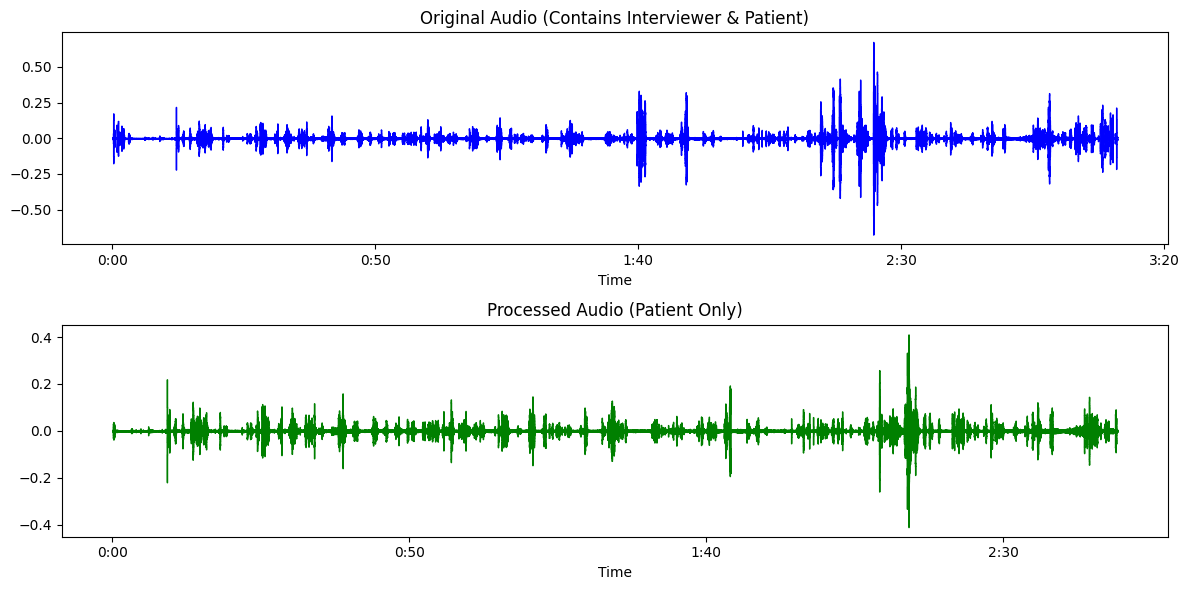

In [ ]:
# Visual Test (Waveform Visualization Before & After)

import librosa
import librosa.display


def plot_waveforms(original_path, processed_path):
    y_orig, sr_orig = librosa.load(original_path, sr=None)
    y_proc, sr_proc = librosa.load(processed_path, sr=None)

    fig, ax = plt.subplots(nrows=2, sharex=False, figsize=(12, 6))
    librosa.display.waveshow(y_orig, sr=sr_orig, ax=ax[0], color="blue")
    ax[0].set(title='Original Audio (Contains Interviewer & Patient)')

    librosa.display.waveshow(y_proc, sr=sr_proc, ax=ax[1], color="green")
    ax[1].set(title='Processed Audio (Patient Only)')
    plt.tight_layout()
    plt.show()

plot_waveforms("local_data/audio/adrso025.wav", "local_data/processed_audio/adrso025_par.wav")


# Transcribe participant speech

In [ ]:
# Generate a dataframe holding participant_id, category, audio_path, and transcript text),
# iterate through the processed_audio folder,
# run Whisper on each file, and store the results.

import whisper

# Load the model
 # (Note: 'small' provides a good balance,
 # but may take some time to run on CPU/Colab standard GPUs)
print("Loading Whisper model...")
asr_model = whisper.load_model("small")

def generate_transcript(audio_path):
    """Generates the transcript for a given audio file, forcing verbatim output."""

    # Uncomment this when running on a CPU,
      # because 16-bit floating-point precision requires GPU.
      # When fp16=false, it falls back to FP32 (32-bit).
    # fp16=False

    # A sample prompt loaded with disfluencies to tell Whisper we WANT the stutters and fillers in the transcribed texts
    disfluent_prompt = "Um, uh, well, the... the boy is... he is falling, and, um, the water is running."

    result = asr_model.transcribe(
        audio_path,
        language="en",
        initial_prompt=disfluent_prompt
    )
    return result["text"]



Loading Whisper model...


100%|████████████████████████████████████████| 461M/461M [00:01<00:00, 253MiB/s]


In [ ]:
# List to hold the row dictionaries before converting to a DataFrame
transcription_data = []

# Find all the processed participant audio files
processed_audio_dir = "local_data/processed_audio/"
audio_files = glob.glob(f"{processed_audio_dir}*_par.wav")

print(f"Found {len(audio_files)} files to transcribe. Starting...")

for audio_path in audio_files:
    # Extract participant ID from filename (e.g., 'adrso025_par.wav' -> 'adrso025')
    file_name = os.path.basename(audio_path)
    participant_id = file_name.replace("_par.wav", "")
    print(f"  Transcribing {participant_id}...")

    try:
        transcript = generate_transcript(audio_path)
        # Append the data to our list
        transcription_data.append({
            "participant_id": participant_id,
            "audio_path": audio_path,
            "transcript": transcript.strip()
        })
    except Exception as e:
        print(f"  [Error] Failed to transcribe {participant_id}: {e}")

# Generate the DataFrame
df = pd.DataFrame(transcription_data)

# Load the ground truth CSV file
gt_df = pd.read_csv("local_data/ground_truth.csv")

# Merge the transcripts with the labels based on 'participant_id'
final_df = pd.merge(df, gt_df, on="participant_id", how="inner")

print("\nTranscription complete!")

Found 161 files to transcribe. Starting...
  Transcribing adrso054...
  Transcribing adrso007...
  Transcribing adrso128...
  Transcribing adrso309...
  Transcribing adrso274...
  Transcribing adrso005...
  Transcribing adrso215...
  Transcribing adrso315...
  Transcribing adrso164...
  Transcribing adrso273...
  Transcribing adrso142...
  Transcribing adrso232...
  Transcribing adrso156...
  Transcribing adrso300...
  Transcribing adrso299...
  Transcribing adrso211...
  Transcribing adrso074...
  Transcribing adrso233...
  Transcribing adrso188...
  Transcribing adrso089...
  Transcribing adrso162...
  Transcribing adrso223...
  Transcribing adrso126...
  Transcribing adrso161...
  Transcribing adrso032...
  Transcribing adrso218...
  Transcribing adrso060...
  Transcribing adrso220...
  Transcribing adrso125...
  Transcribing adrso130...
  Transcribing adrso106...
  Transcribing adrso012...
  Transcribing adrso264...
  Transcribing adrso153...
  Transcribing adrso110...
  Transcribi

### Verification

In [ ]:
display(final_df.head())

,participant_id,audio_path,transcript,label,label_numeric
0,adrso054,local_data/processed_audio/adrso054_par.wav,I'm gonna keep burying the meal. I'm gonna hav...,AD,1
1,adrso007,local_data/processed_audio/adrso007_par.wav,Our mother standing by the sink kind of looks ...,CN,0
2,adrso128,local_data/processed_audio/adrso128_par.wav,"Um, Cookie John, and he's stepping on us, well...",AD,1
3,adrso309,local_data/processed_audio/adrso309_par.wav,"Mother is, um, drying the dishes, looking out ...",CN,0
4,adrso274,local_data/processed_audio/adrso274_par.wav,"Alright, the boy is taking a cookie out of the...",CN,0


### Transcripts - Before and After Interviewer Removal

In [ ]:
import textwrap
import re
import os

# Define the target
participant_target = 'adrso025'
original_audio_path = f"local_data/audio/{participant_target}.wav"

print(f"      ORIGINAL TRANSCRIPT: {participant_target}      \n")

if os.path.exists(original_audio_path):
    # print("Transcribing uncut original audio (this may take a moment)...\n")

    # We use the disfluent prompt to try and capture the stutters
    disfluent_prompt = "Um, uh, well, the... the boy is... he is falling, and, um, the water is running."

    # Run Whisper on the RAW audio (which contains both interviewer and participant)
    result = asr_model.transcribe(
        original_audio_path,
        language="en",
        initial_prompt=disfluent_prompt
    )

    full_text = result["text"].strip()

    # Split the Whisper text by standard sentence delimiters (. ? !)
    utterances = [u.strip() for u in re.split(r'(?<=[.!?]) +', full_text) if u.strip()]

    for utterance in utterances:
        # Capitalize the first letter for a polished look
        clean_utterance = utterance.capitalize()

        # Wrap the text to 70 characters
        wrapped_utterance = textwrap.fill(
            f" {clean_utterance}",
            width=70,
            subsequent_indent="  "
        )
        print(wrapped_utterance)
        print() # Blank space between utterances

else:
    print(f"Could not find the original audio file at {original_audio_path}")

      ORIGINAL TRANSCRIPT: adrso025      

 Tell me everything that's going on.

 Well, um, the kids that are working on the water in the corner, um,
  they're grading, they are going to, um, get, uh, some cookies from
  the cookie jar, and, uh, the mother doesn't see it because she's
  inside of, you know, drying the clothes, and, uh, the kids then
  just, uh, i guess, do the picture that, um, mother that's working
  hard and the kids which were playing, and, uh, all of a sudden, um,
  somebody's, uh, uh, turned over a dish and, uh, all over the floor,
  except that it did not dry, uh, could, it didn't, um, splash from
  the, it was splash from the sink, but not from, uh, no, that's not,
  uh, too, too, trying to get too much out of it.

 That's okay.

 Is there anything else?

 Well, one of the kids is going to get, uh, crack on the head, and
  maybe has a, um, uh, uh, a weak image, you know, to speak, and
  sometimes i just, i just, why is it, you know.

 Most, there anything else t

In [ ]:
# Filter the dataframe for the specific participant ID
sample_row = final_df[final_df['participant_id'] == 'adrso025']

# Check if the participant exists in the dataframe, then print
if not sample_row.empty:
    # .values[0] extracts just the text string instead of the whole pandas series
    transcript_text = sample_row['transcript'].values[0]
    print(f"Transcript for adrso025:\n\n{transcript_text}")
else:
    print("Could not find adrso025 in the dataframe.")

Transcript for adrso025:

Um, well, the kids are working on the corner. Um, we're grading, and they are going to, um, get, uh, some cookies from the cookie jar, and, uh, the mother doesn't see it because she's inside, you know, drying the clothes, and, uh, the kids then just, uh, I guess, there's a picture that, um, the mother is working hard, and the kids were playing, and, uh, all of a sudden, um, somebody's, uh, uh, uh, turned over a dish, and, uh, pulled over the floor, except that it did not dry, uh, could, it didn't, um, splash from the... it splashed from the sink, but not from... um, uh, no, that's not... too, too, trying to get too much out of it. Well, well, one of the kids is going to get a crack on the head, and maybe has a, um, uh, it's so, sometimes I see it very clearly, and, uh, other times I see a weak image speak, and sometimes I just sort of, what is it? Mostly, uh, is I have, not so much trouble, uh, in, I, in, uh, looking at a thing, in it as a, um, as an, an image

In [ ]:
import textwrap
import re

# Filter the dataframe for the specific participant ID in ADDReSSo
participant_target = 'adrso025'
sample_row = final_df[final_df['participant_id'] == participant_target]

if not sample_row.empty:
    transcript_text = sample_row['transcript'].values[0]

    # Create a clean header
    print(f"               TRANSCRIPT: {participant_target}                  \n")

    # Split the text by standard sentence delimiters (. ? !) followed by a space
    # The (?<=[.!?]) is a lookbehind that keeps the punctuation attached to the sentence
    utterances = [u.strip() for u in re.split(r'(?<=[.!?]) +', transcript_text) if u.strip()]

    for utterance in utterances:
        # Capitalize the first letter for a polished look
        clean_utterance = utterance.capitalize()

        # Wrap the text to 70 characters
        wrapped_utterance = textwrap.fill(
            f" {clean_utterance}",
            width=70,
            subsequent_indent="  "
        )
        print(wrapped_utterance)
        print() # Adds a blank space between utterances for readability

else:
    print(f"Could not find {participant_target} in the dataframe.")

               TRANSCRIPT: adrso025                  

 Um, well, the kids are working on the corner.

 Um, we're grading, and they are going to, um, get, uh, some cookies
  from the cookie jar, and, uh, the mother doesn't see it because
  she's inside, you know, drying the clothes, and, uh, the kids then
  just, uh, i guess, there's a picture that, um, the mother is working
  hard, and the kids were playing, and, uh, all of a sudden, um,
  somebody's, uh, uh, uh, turned over a dish, and, uh, pulled over the
  floor, except that it did not dry, uh, could, it didn't, um, splash
  from the...

 It splashed from the sink, but not from...

 Um, uh, no, that's not...

 Too, too, trying to get too much out of it.

 Well, well, one of the kids is going to get a crack on the head, and
  maybe has a, um, uh, it's so, sometimes i see it very clearly, and,
  uh, other times i see a weak image speak, and sometimes i just sort
  of, what is it?

 Mostly, uh, is i have, not so much trouble, uh, in, 

# Upload the created files into the GCP Bucket

In [ ]:

# Method to upload to bucket
def upload_to_gcs(local_file_path, gcs_destination_blob_name):
    """Uploads a single file to the GCS bucket."""
    blob = bucket.blob(gcs_destination_blob_name)
    blob.upload_from_filename(local_file_path)

# 1. Save final merged transcript dataframe to a local CSV
print("Saving final dataframe to local CSV...")
final_csv_path = "local_data/final_transcripts.csv"
final_df.to_csv(final_csv_path, index=False)

# 2. Upload the CSVs to a new 'processed' folder in the bucket
print("Uploading CSVs to GCS...")
upload_to_gcs("local_data/ground_truth.csv", "ADDReSS2021/processed/ground_truth.csv")
upload_to_gcs(final_csv_path, "ADDReSS2021/processed/final_transcripts.csv")

# 3. Upload all the processed participant audio files
processed_files = glob.glob("local_data/processed_audio/*_par.wav")
print(f"Starting upload of {len(processed_files)} audio files. This might take a minute...")

for local_audio in processed_files:
    file_name = os.path.basename(local_audio)
    gcs_path = f"ADDReSS2021/processed/audio/{file_name}"

    upload_to_gcs(local_audio, gcs_path)

print("Success! All local data is backed up to GCS.")

Saving final dataframe to local CSV...
Uploading CSVs to GCS...
Starting upload of 161 audio files. This might take a minute...
Success! All local data is backed up to GCS.
